# Processamento dos resultados

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy import stats
import pandas as pd
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
from matplotlib.ticker import AutoMinorLocator
def db2pow(x_db):
    return 10**( x_db / 10.0 )
def pow2db(x):
    return 10 * np.log10(x)

In [2]:
# Número de subconjuntos usados nas simulações
num_sections = 20
# Número de amostras por loop
num_samples_p = 100000
# Número total de amostras
num_samples = 1000000

p_num_drops = 100

# Arquivo de dados de interferência para leitura
basefile = 'system_inr.csv'
# Arquivo de dados de interferência total
file_totalintf = 'system_inr_total.csv'
# Caminhos base
basepaths_preffix = 'IMT_TO_SES_Database_BASE_estacoes_000'

origin = Path("./")

preffix = f'{basepaths_preffix}'

dirs = [p for p in origin.iterdir() if p.is_dir() and p.name.startswith(preffix)]
for dirn in dirs:

    filename = f'{dirn}/{basefile}'
    print(f'Processando monte carlo em {filename}')
    # Carregar os dados
    intf_array = db2pow( pd.read_csv(filename).values )
    # Número de snapshots
    num_snaps = int( len( intf_array ) / num_sections )
    # Transformar em uma matriz
    intf_matrix = np.reshape(intf_array, (num_snaps, num_sections))
    # Inicialização do arranjo de interferência total
    total_intf = np.zeros(num_samples)

    num_iter = round(num_samples / num_samples_p)
    for n in range(num_iter):
        # Linhas aleatórias
        rows = np.random.randint(0, num_snaps, size=(num_samples_p, num_sections))
        # Colunas
        cols = np.tile(np.arange(num_sections), (num_samples_p, 1))
        # Dados aglomerados aleatoriamente
        selected = intf_matrix[rows, cols]
        # Soma
        summed = np.sum(selected, axis=1)

        total_intf[n*num_samples_p:(n+1)*num_samples_p] = pow2db(summed)
        
    np.savetxt(f'{dirn}/{file_totalintf}', total_intf, delimiter=",", fmt="%.6f", header='dados')


Processando monte carlo em IMT_TO_SES_Database_BASE_estacoes_000019_SUL_2026-07-24_06/system_inr.csv
Processando monte carlo em IMT_TO_SES_Database_BASE_estacoes_000017_SUL_2026-07-24_02/system_inr.csv
Processando monte carlo em IMT_TO_SES_Database_BASE_estacoes_000014_SUL_2026-07-24_02/system_inr.csv
Processando monte carlo em IMT_TO_SES_Database_BASE_estacoes_000012_SUL_2026-07-24_07/system_inr.csv


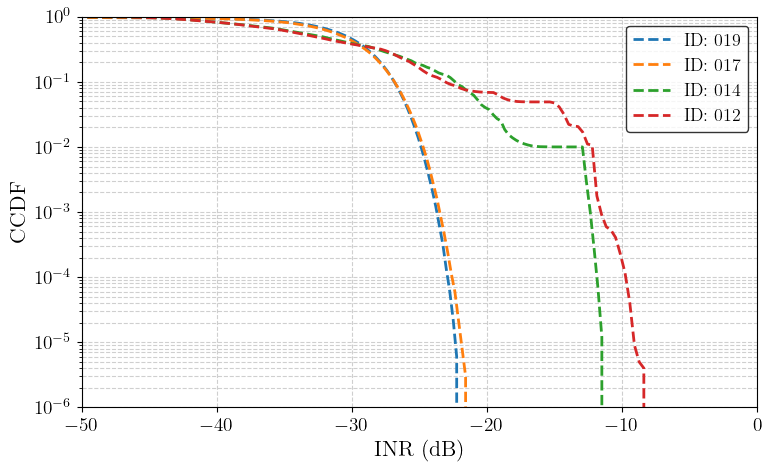

In [4]:

plt.rcParams.update({
    "text.usetex": True,
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "lines.linewidth": 2,
    "figure.figsize": (8,5),
    "font.family": "serif",
})

# Arquivo de dados de interferência para leitura
basefile = 'system_inr_total.csv'
# Arquivo de dados de interferência total
file_totalintf = 'system_inr_total.csv'
# Caminhos base
basepaths_preffix = 'IMT_TO_SES_Database_BASE_estacoes_000'


# Cores da figura
num_colors = len(bwv)
cmap = plt.cm.jet_r
colors = cmap(np.linspace(0, 1, num_colors))

origin = Path("./")

preffix = f'{basepaths_preffix}'

dirs = [p for p in origin.iterdir() if p.is_dir() and p.name.startswith(preffix)]
for dirn in dirs:

    filename = f'{dirn}/{basefile}'
    dirstr = str(dirn)
    id_bs = dirstr.split('_')[6][-3:]
    
    # Carregar os dados
    intf_array_db = pd.read_csv(filename).values
    intf_array_db = np.reshape(intf_array_db, (len(intf_array_db), ))
    # Eixo de interferência
    intf_ax = np.linspace( np.min(intf_array_db), np.max(intf_array_db), 200 )
    
    # Calculo da CDF
    ecdf_s = stats.ecdf( intf_array_db ).cdf
    eccdf = 1 - np.array([ ecdf_s.evaluate( xp ) for xp in intf_ax ])
    plt.semilogy(intf_ax, eccdf, ls='--', label=f'ID: {id_bs}')
    plt.ylim(1e-6,1)
    plt.xlim(-50,0)
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.xlabel("INR (dB)")
    plt.ylabel("CCDF")
    # plt.title(f"Largura de banda: {bw} MHz, Arranjo: 8$\\times${num_cols}")
    plt.legend(
        frameon=True,
        facecolor='white',
        edgecolor='black',
        framealpha=0.8,
        fontsize=13,
        loc='best',
    )
    plt.tight_layout()
plt.savefig(f"./ccdf_partial.png", dpi=300, bbox_inches="tight")
plt.show()